# Configuration

In [2]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import networkx as nx
import dill


# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')
from pdata.data_read import read_unibind_file
from benchmark.benchmark_model import analysis_tf_recovery

from benchmark.benchmark_model import analysis_tf_gene_data, analysis_tf_gene_all_correlation, \
    plot_top_n_tf_comparison, dyg_tf_gene_result
    
from benchmark.benchmark_model import analysis_tf_gene_all_precision


from benchmark.benchmark_model import analysis_tf_region

from benchmark.benchmark_model import plot_top_n_comparison

from benchmark.benchmark_model import analysis_region_gene, evaluate_r2g_benchmark, \
    plot_recovery_curves, plot_top_n_methods_comparison
    
from benchmark.benchmark_model import analysis_tf_gene_per_tf_precision, \
    analysis_tf_gene_correlation_summary, \
    analysis_tf_region_overall, \
    analysis_region_gene_precision
    
from benchmark.benchmark_model import plot_top_n_per_tf_comparison
from benchmark.benchmark_model import analysis_tf_gene_per_tf_topn


cell_type = "K562"
unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/K562/unibind/K562_UniBind_search_ayyh3bfb.tar.gz"


# Result

********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/cell_line/K562/unibind/K562_UniBind_search_ayyh3bfb.tar.gz ...
处理完成！
共提取了 117 个 TF 的数据。
总 Region 数量: 5197171
  chrom   start     end    TF CellLine     SourceID
0  chr1  138970  138989  CTCF     K562  ENCSR000AKO
1  chr1  267998  268017  CTCF     K562  ENCSR000AKO
2  chr1  778800  778819  CTCF     K562  ENCSR000AKO
3  chr1  869917  869936  CTCF     K562  ENCSR000AKO
4  chr1  904767  904786  CTCF     K562  ENCSR000AKO
    CellLine     TF  PeakCount  Rank
112     K562    WT1     117299   1.0
83      K562   PBX2     110496   2.0
39      K562  GATA1      96140   3.0
15      K562   CTCF      73652   4.0
57      K562    MAX      73610   5.0
Top 40 AUC (Raw): 649.00
Top 40 AUC (Normalized): 0.8118


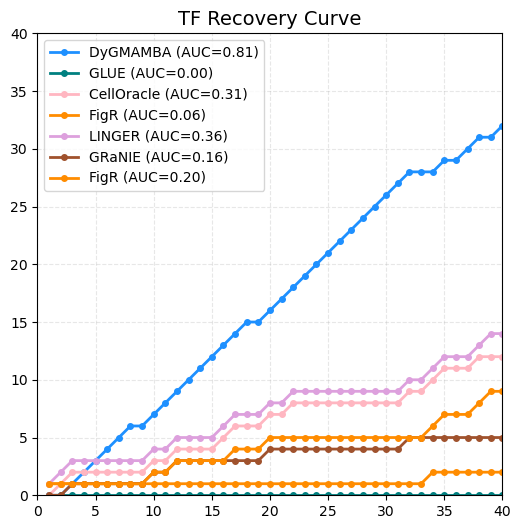

In [3]:

flag_tf_recovery = True
flag_tf_region = True
flag_tf_gene = True
flag_region_gene = True

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmark/"

os.makedirs(output_path, exist_ok=True )

unibind_df_file = data_path + "benchmark/unibind_df.pkl"

model_result_path = data_path + "data_dyg/"

method_list = ["DyGMamba", "CellOracle", "FigR", "GLUE", "LINGER", "GRaNIE", "Pando"]

#############################################################################
#
# Unibind data processing
#
#############################################################################

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")


##############################################################################
#
# TF recovery
#
##############################################################################
if flag_tf_recovery == True:
    analysis_tf_recovery(data_path, output_path, method_list)




# TF Gene


步骤 1: 过滤 Peaks (行)
  > 找到 40990 / 64213 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 717 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (40990, 717)
**************************************************
Peak-Gene: 31406, 2000, edge:1989629
**************************************************
**************************************************
Dygmamba TF-Peak: 55, 9272,        edge: 27493
Peak-Gene: 31406, 2000, edge:1989629
TF-Gene: 55, 1962, edge: 3737079
**************************************************
TF-Gene: 55, 1962, edge: 3737079
avg active TF-Gene: 55, 1962,        edge: 20720
avg global TF-Gene: 55, 1962,        edge: 20720
**************************************************
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
>>> 开始评估预测能力 (Predictability)...
DyGMamba - Precision: 0.1679,                 Recall:

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:558: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:574: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:629: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:648: UserWarning: set_ticklabels() s

[TF-Gene per-TF] DyGMamba: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] GLUE: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] FigR: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] CellOracle: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] LINGER: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] GRaNIE: median Precision=0.0000, median F1.0=0.0000, n_TF=73
[TF-Gene per-TF] Pando: median Precision=0.0000, median F1.0=0.0000, n_TF=73


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:906: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=prec_combined, x="Method", y="Precision",


✓ 已保存：TF-Gene Per-TF Precision Boxplot


...

  ✓ 已保存：Benchmark of TF-Gene Per-TF F_score Top100 F1.png


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, fontsize=10)


  ✓ 已保存：Benchmark of TF-Gene Per-TF Precision Top50.png


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels, fontsize=10)


  ✓ 已保存：Benchmark of TF-Gene Per-TF F_score Top50.png


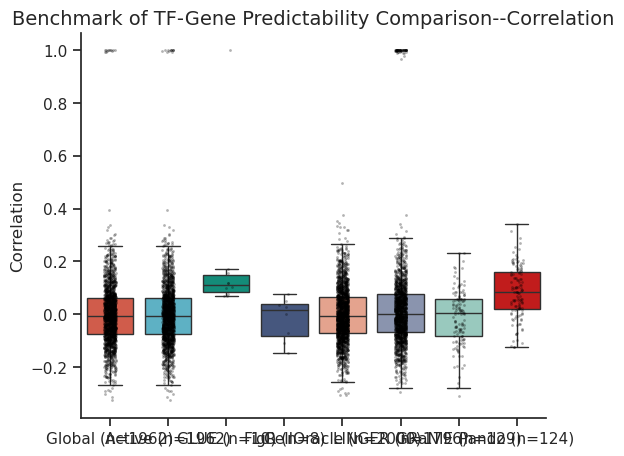

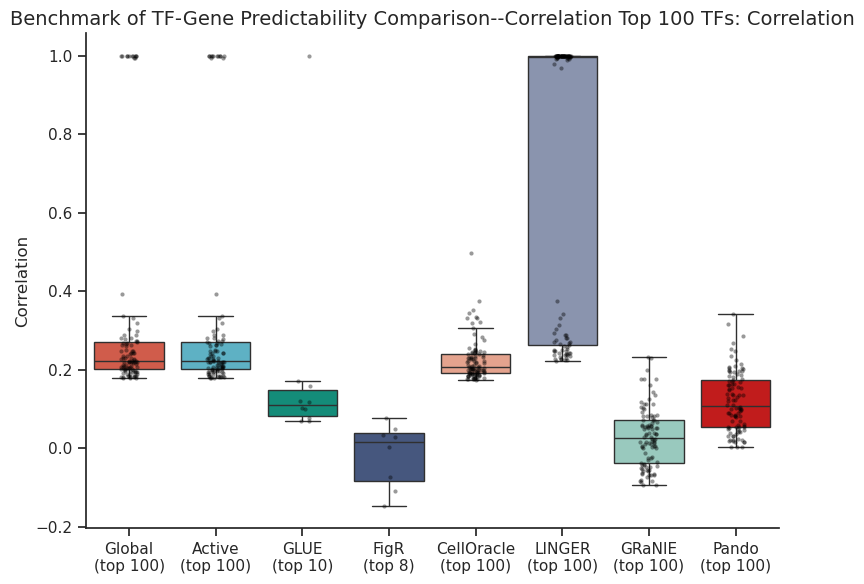

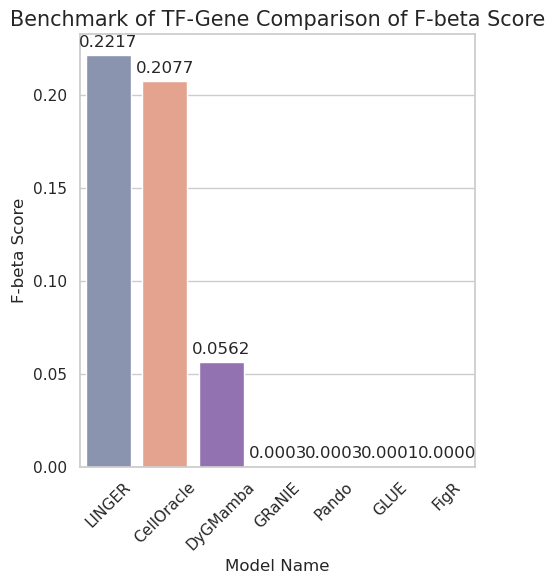

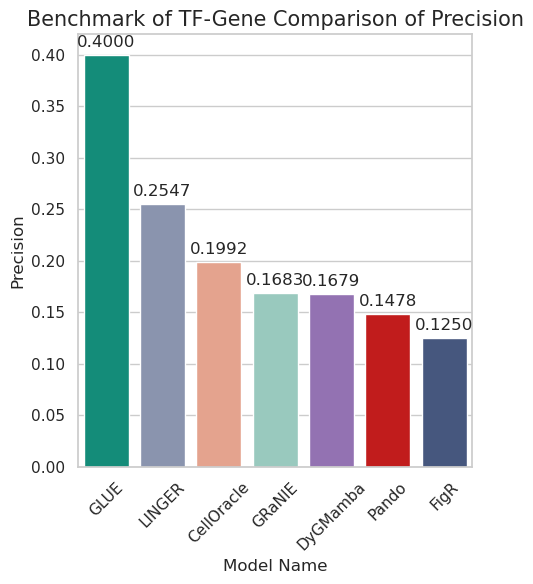

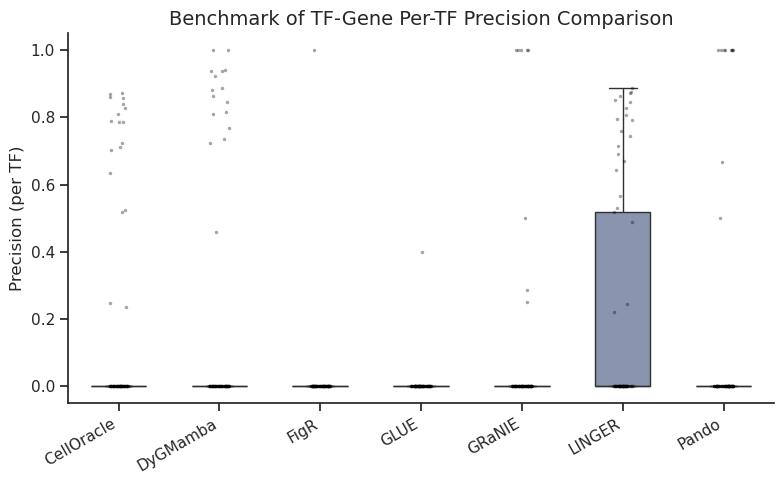

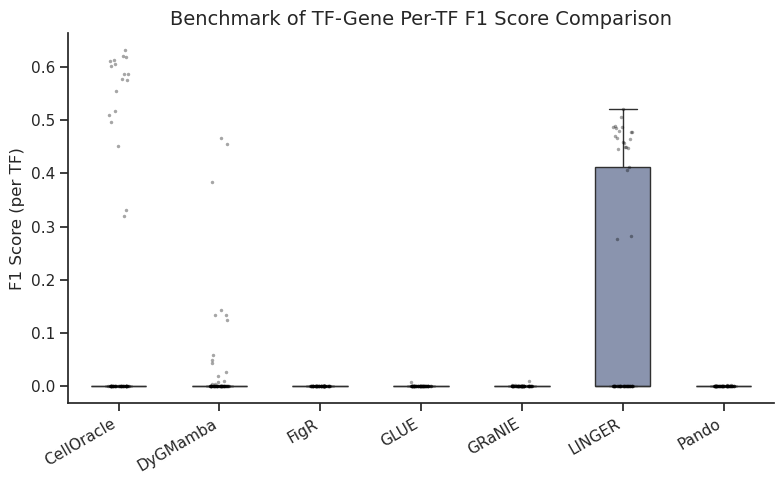

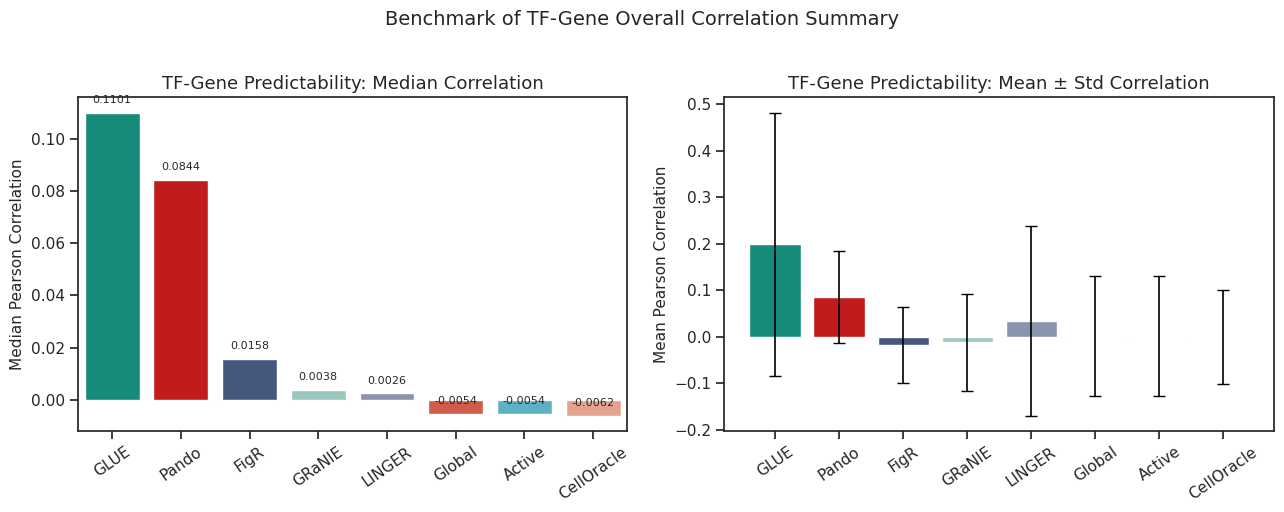

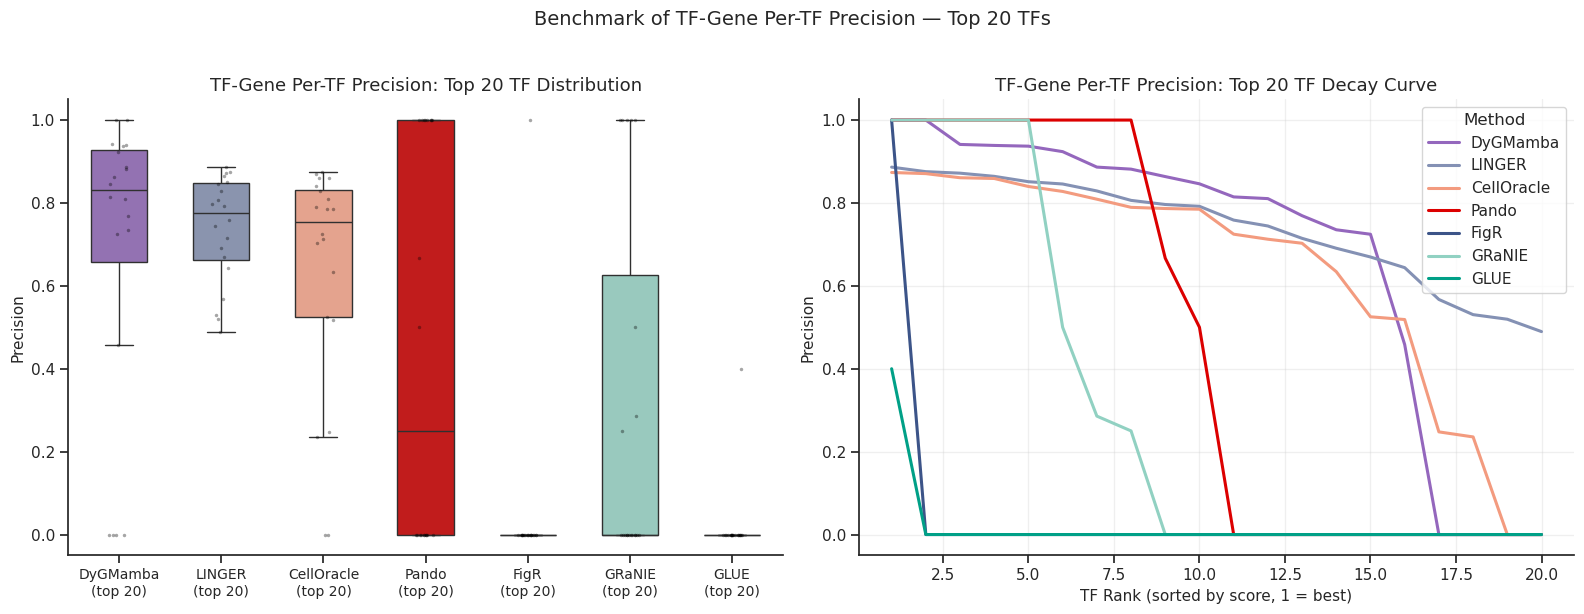

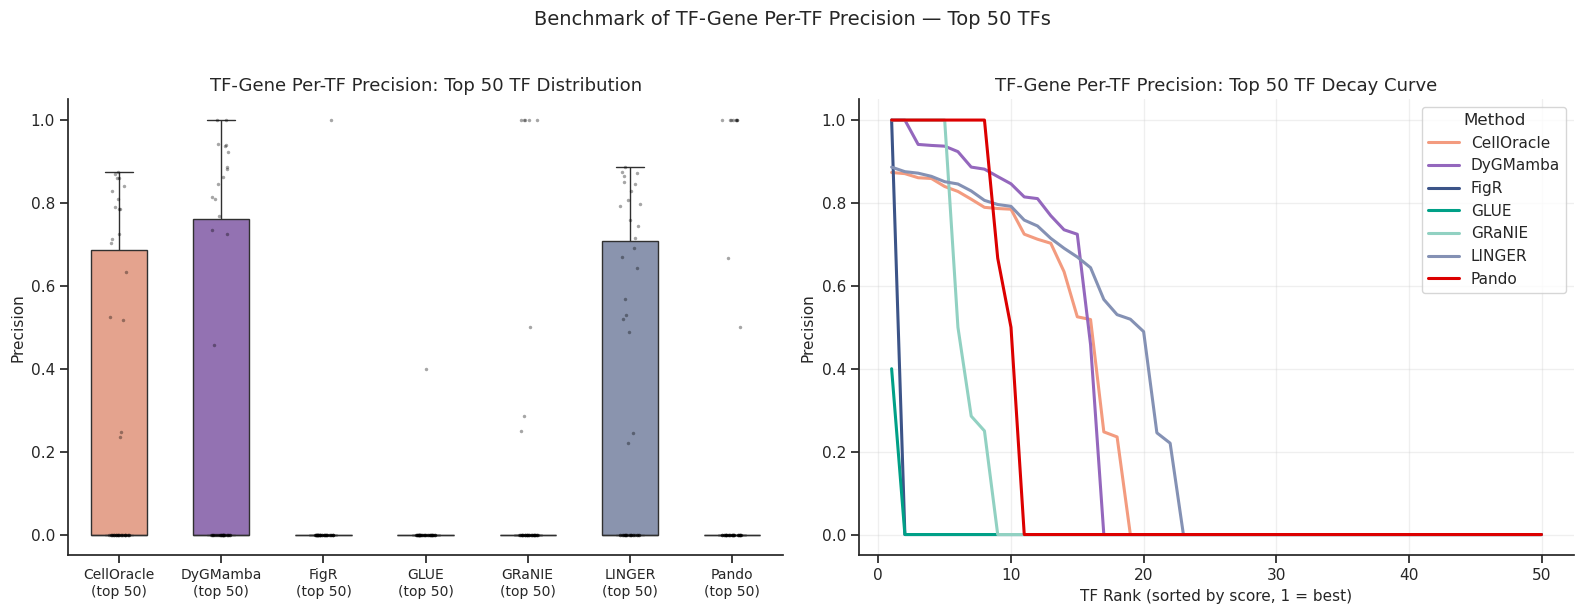

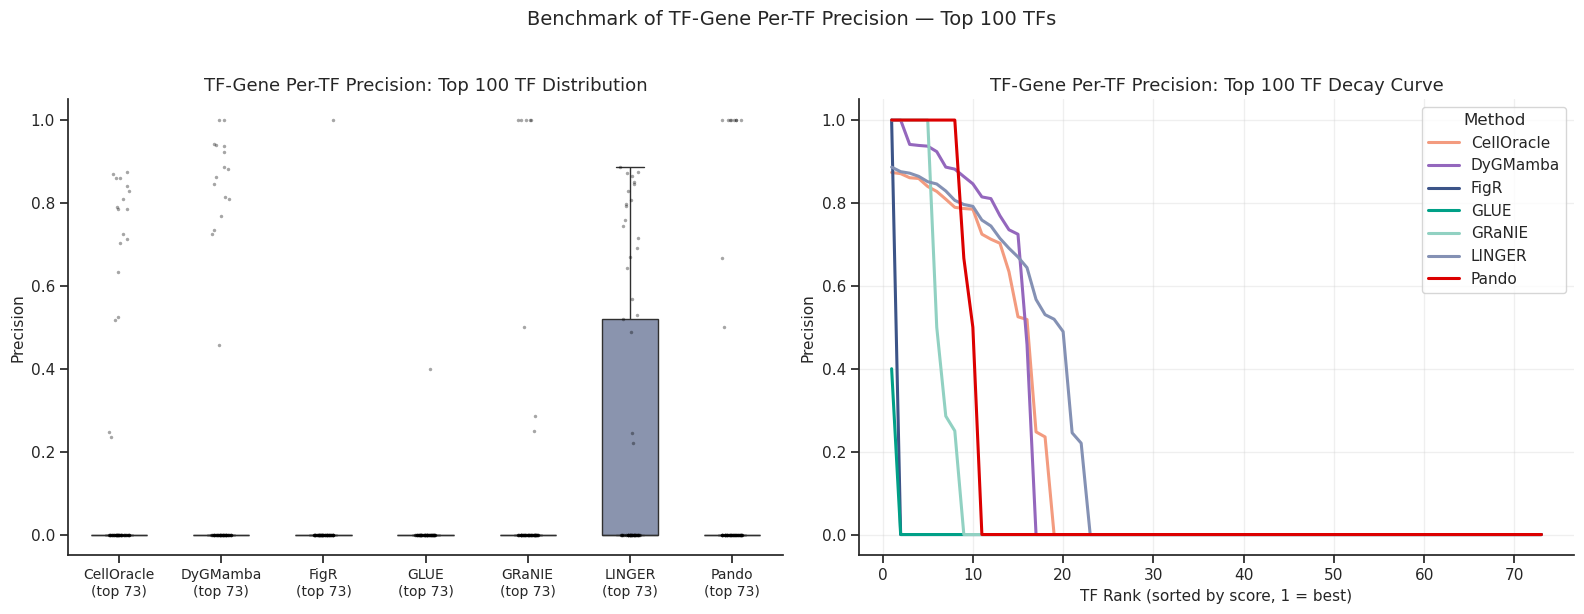

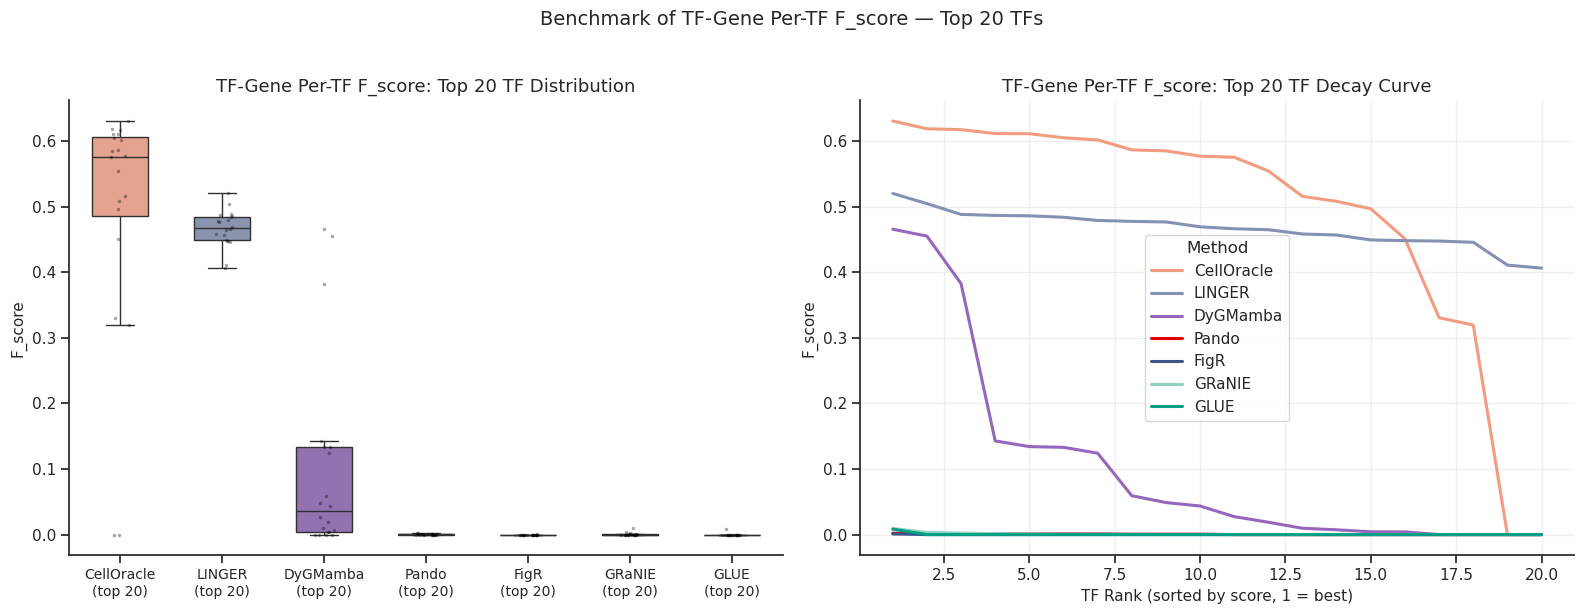

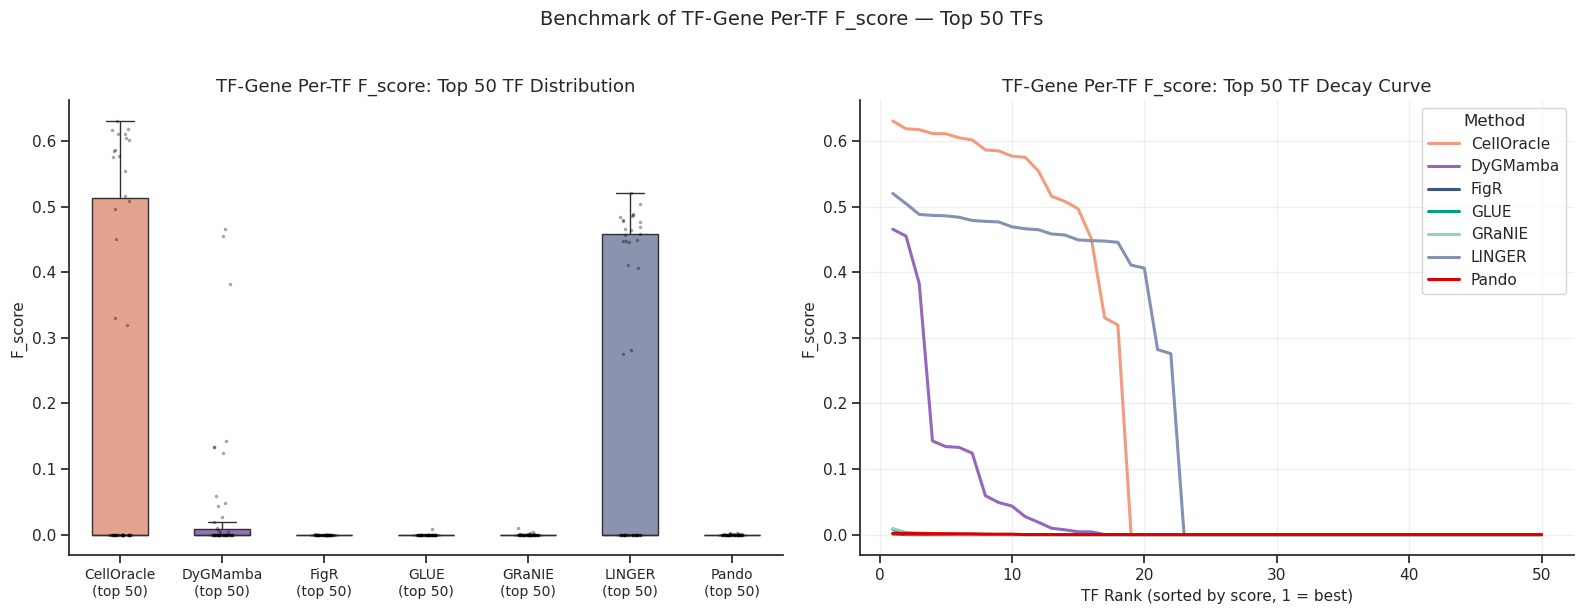

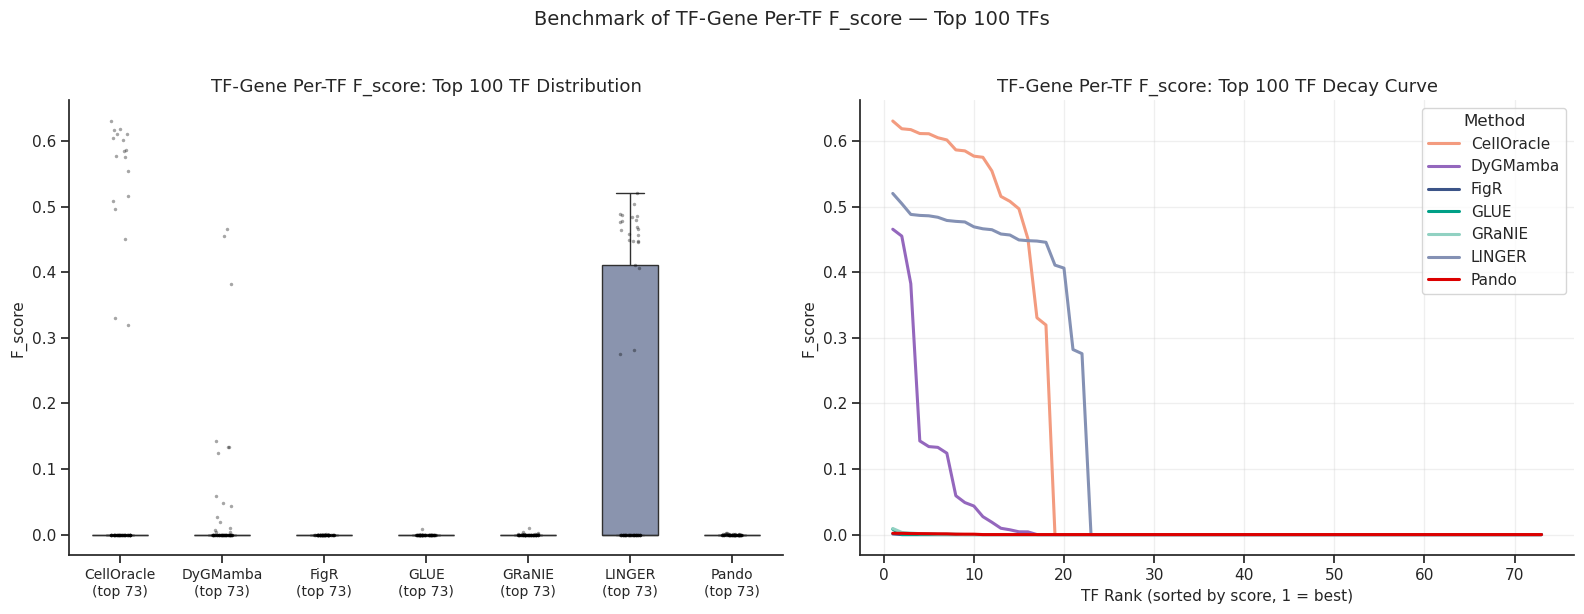

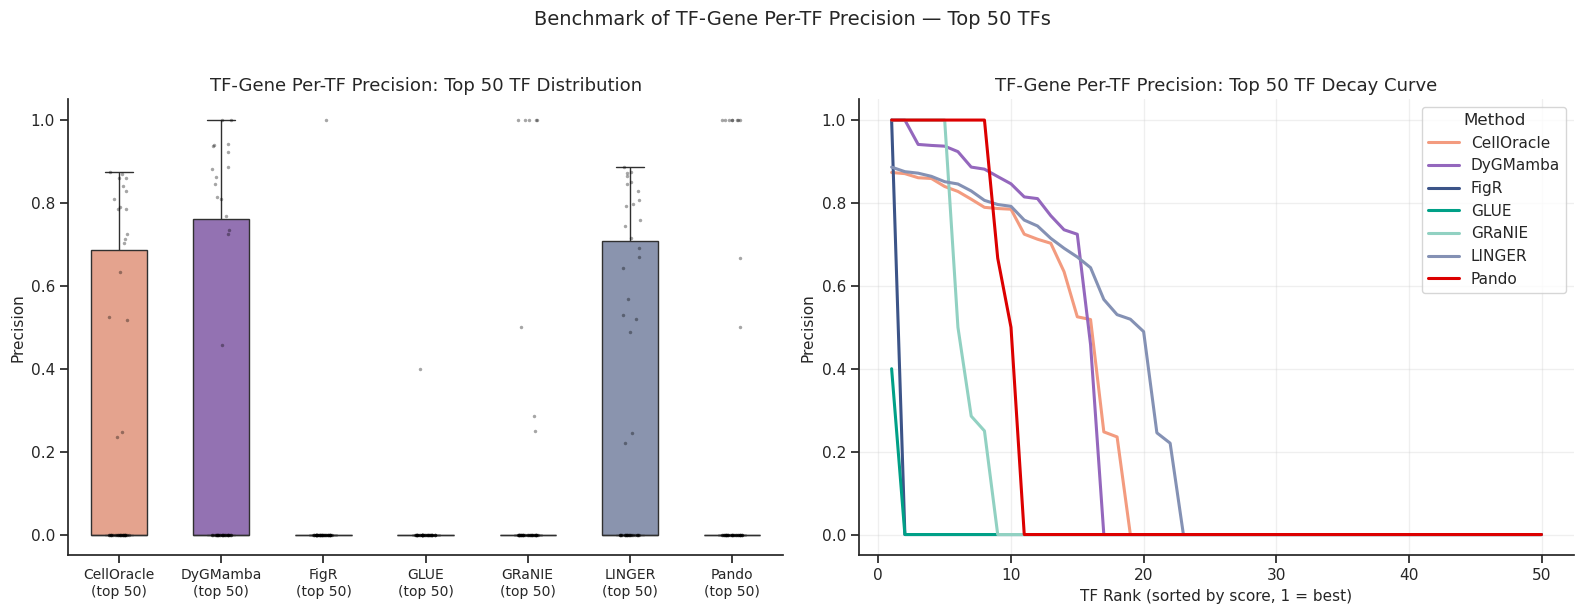

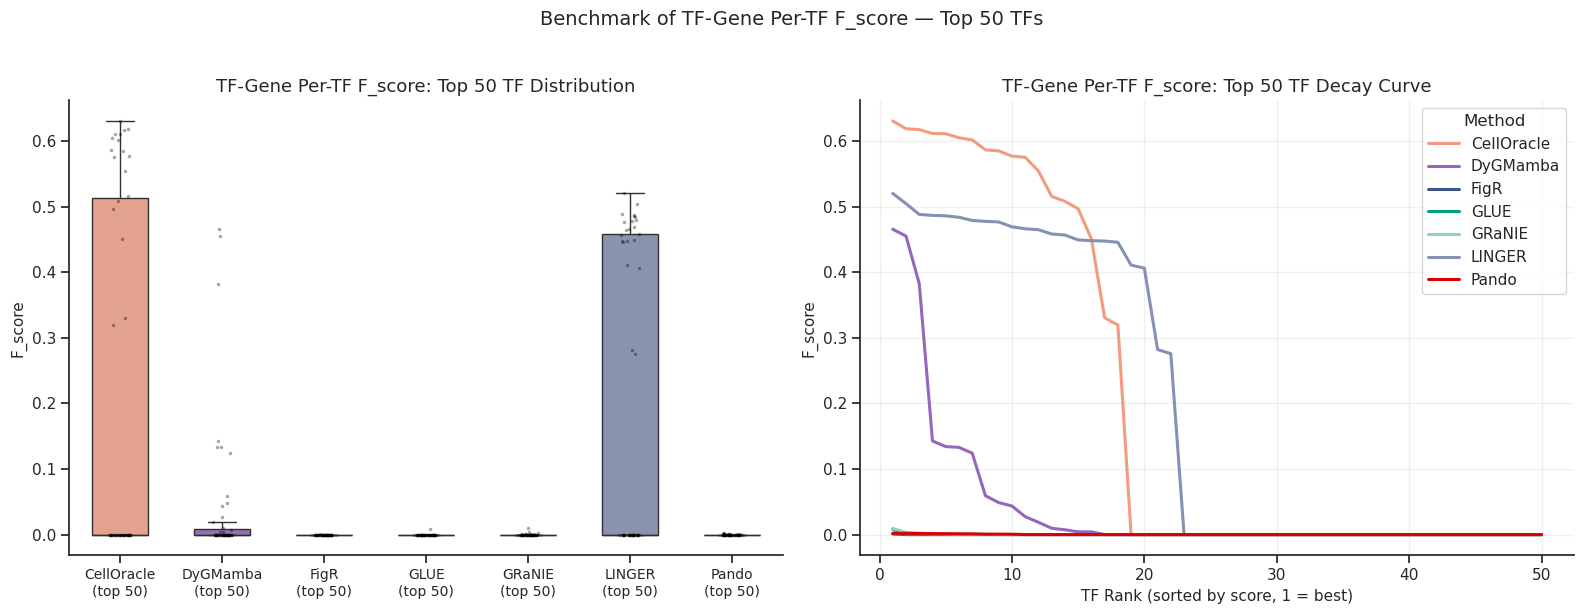

In [ ]:
##############################################################################
#
# TF-Gene
#
##############################################################################
if flag_tf_gene == True:
    
    beta = 1.0
    
    method_colors = {
        "Global": "#E64B35",      # 比如：红色
        "Active": "#4DBBD5",      # 比如：天蓝色
        "DyGMamba": "#9467BD",
        "GLUE": "#00A087",        # 比如：绿色
        "FigR": "#3C5488",        # 比如：深蓝色
        "CellOracle": "#F39B7F",  # 比如：橙色
        "LINGER": "#8491B4",      # 比如：灰蓝色
        "GRaNIE": "#91D1C2",      # 比如：青色
        "Pando": "#DC0000"        # 比如：深红色
    }
    
    tf_gene_grn, avg_active_tf_gene_grn, avg_global_tf_gene_grn = dyg_tf_gene_result(data_path, model_result_path)

    tf_gene_correlation_result_dict, tf_gene_precision_result_dict, \
        precision_result_df, tf_gene_per_precision_dict = analysis_tf_gene_data( data_path, method_list, 
                                                            flag_corr = True, flag_precision = True, 
                                                            beta = beta)

    analysis_tf_gene_all_correlation(output_path, tf_gene_correlation_result_dict, method_colors)

    ###########################
    # Top 100 correlation

    # 1. 定义绘图顺序
    my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

    plot_top_n_tf_comparison(tf_gene_correlation_result_dict, 
                             output_path, method_colors, top_n=100, 
                             score_col='Correlation', my_order=my_order)

    #############################
    # Total correlation

    analysis_tf_gene_all_precision(precision_result_df, output_path, method_colors)
    

    tf_gene_prec, tf_gene_fscore, tf_gene_rec =\
        analysis_tf_gene_per_tf_precision(tf_gene_per_precision_dict, output_path, method_colors, beta=beta)

    # 补充分析 2（直接复用已有 result_dict）
    analysis_tf_gene_correlation_summary(tf_gene_correlation_result_dict, output_path, method_colors)

    analysis_tf_gene_per_tf_topn(tf_gene_per_precision_dict, output_path = output_path,
                                 top_n_list  = [20, 50, 100], beta        = beta,
                                 method_colors = method_colors)
   


# TF-region

--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 31421
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 4274788
--- 3. 计算重叠 (构建 Network) ---
构建了包含 376918 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (31421, 73) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 40990 / 64213 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 717 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (40990, 717)
正在解析 Consensus Peaks 坐标...
共发现 16 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 11 个共有 TF，开始评估...
格式已是连字符（chr1-100-200），无需转换。
正在解析 Consensus Peaks 坐标...
共发现 15 个共有 TF，开始评估...


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1364: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1364: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  
/tmp/ipykernel_53863/369657885.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=tf_region_df_combined,
/tmp/ipykernel_53863/369657885.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

[TF-Region Overall] DyGMamba | Macro Prec=0.7446 F=0.0535 | Micro Prec=0.6732 F=0.0619 | N=16
[TF-Region Overall] GLUE | Macro Prec=0.5654 F=0.1732 | Micro Prec=0.6347 F=0.1687 | N=22
[TF-Region Overall] LINGER | Macro Prec=0.1729 F=0.2569 | Micro Prec=0.1729 F=0.2569 | N=22
[TF-Region Overall] GRaNIE | Macro Prec=0.6162 F=0.0540 | Micro Prec=0.4783 F=0.0492 | N=11
[TF-Region Overall] Pando | Macro Prec=0.5444 F=0.0307 | Micro Prec=0.4857 F=0.0279 | N=15


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1880: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  def analysis_tf_region_overall(tf_region_result, output_path, beta=1.0):
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1880: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  def analysis_tf_region_overall(tf_region_result, output_path, beta=1.0):
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1880: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  def analysis_tf_regi

✓ 已保存：TF-Region Overall Precision and F1
✓ 已保存：TF-Region Macro Precision vs F Score


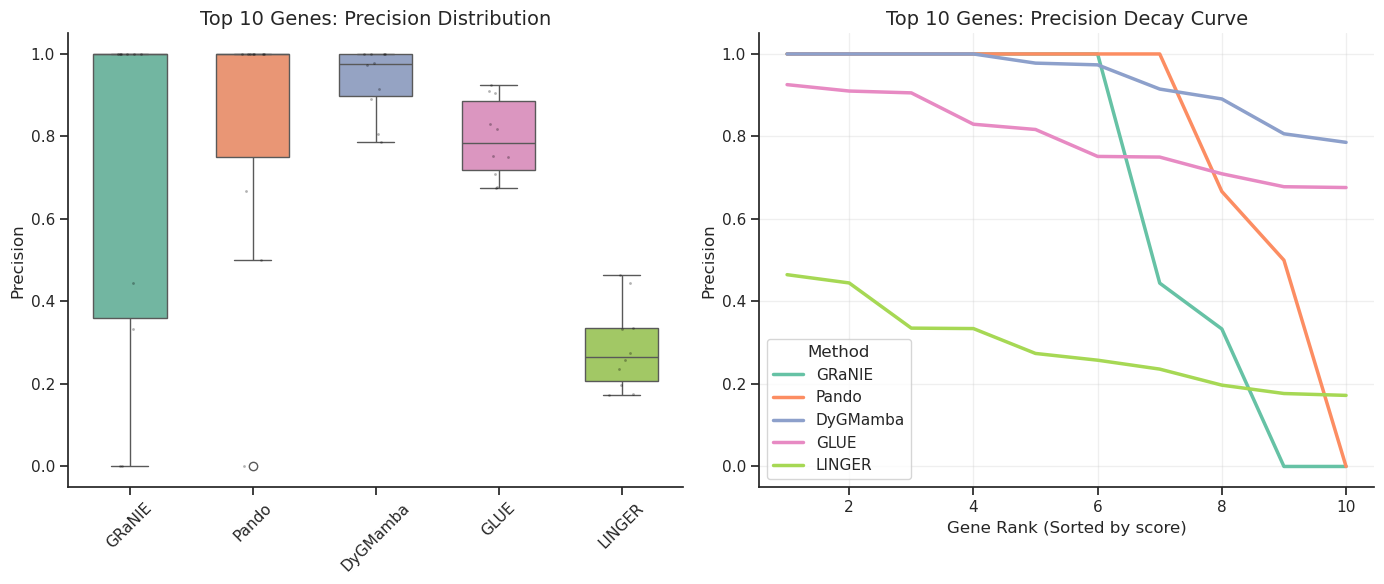

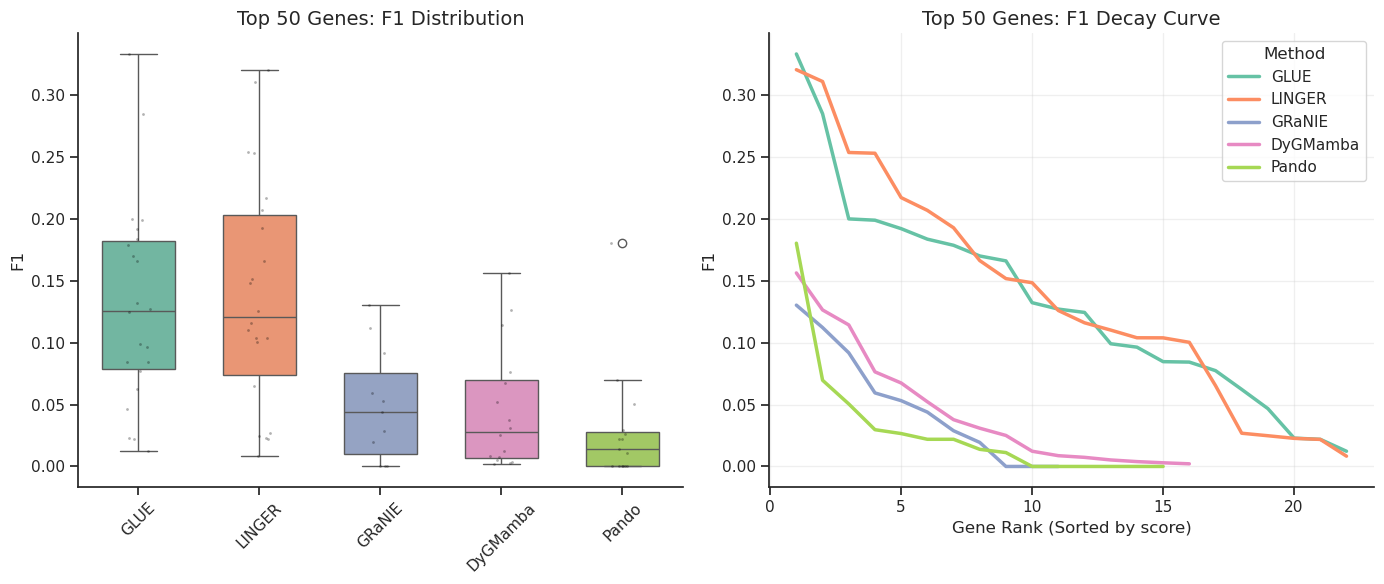

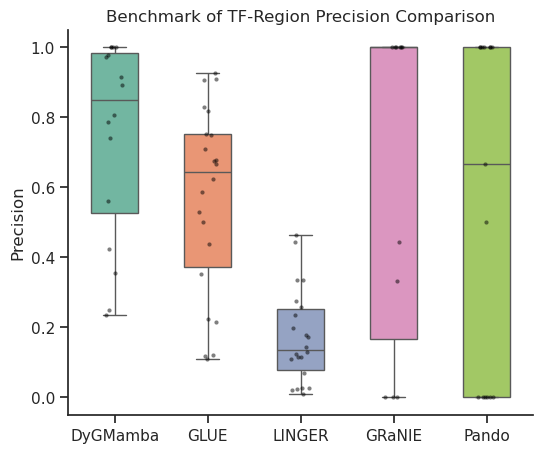

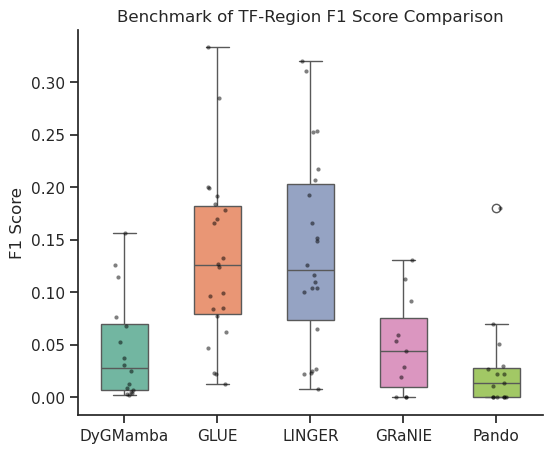

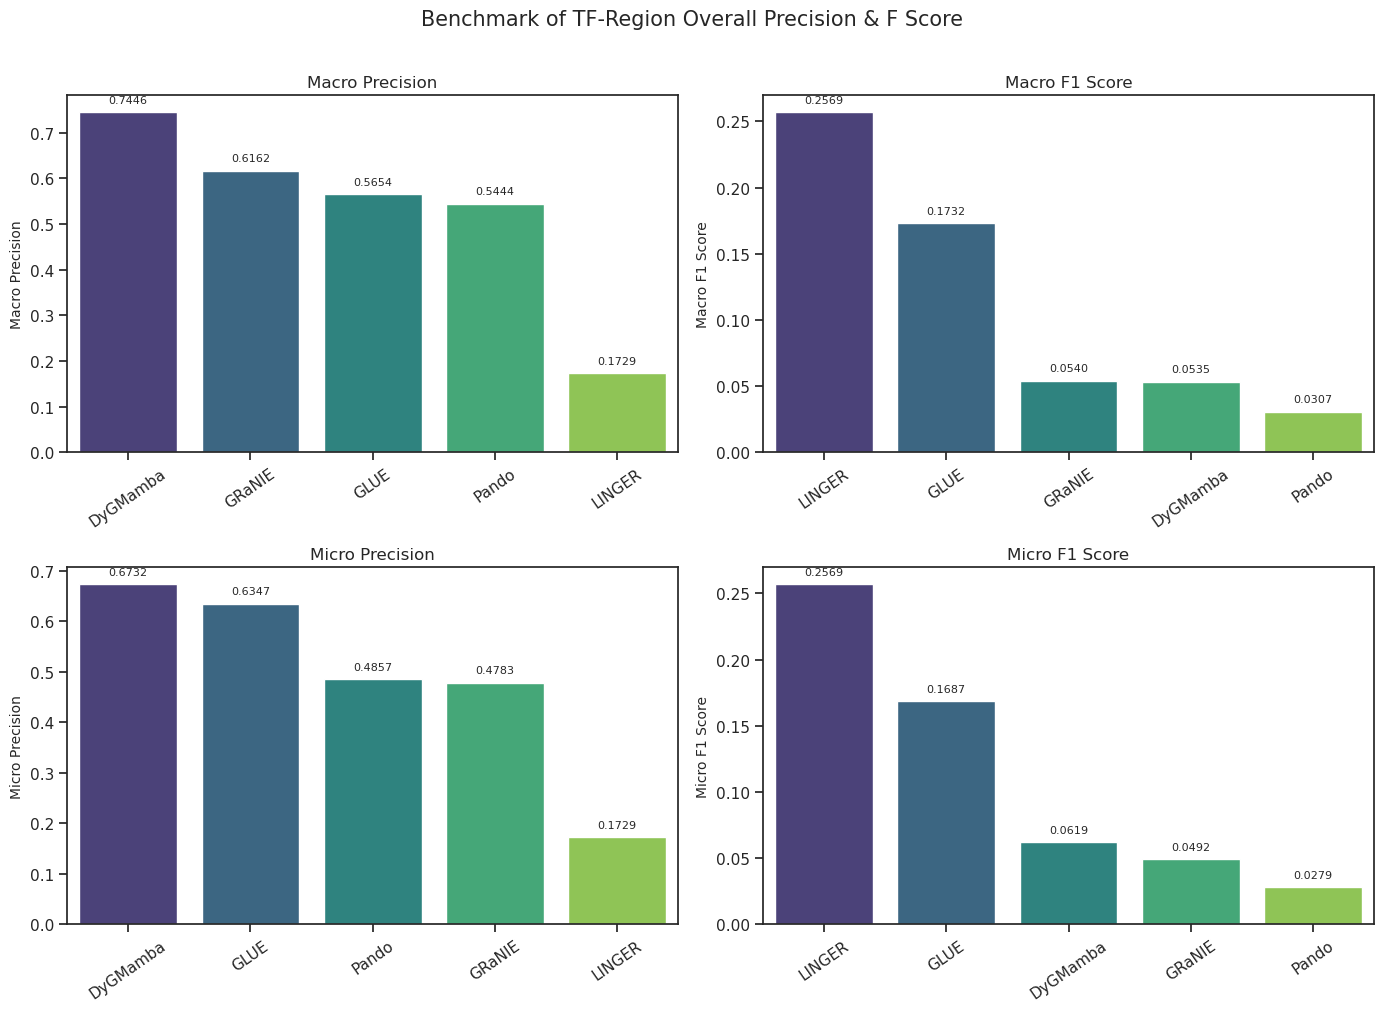

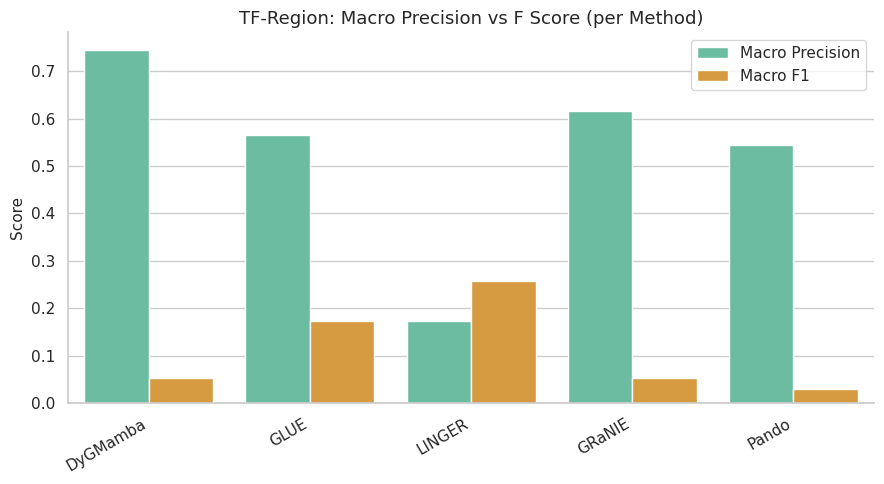

In [6]:

##############################################################################
#
# TF-Region
#
##############################################################################
if flag_tf_region == True:
    ###################################
    # Benchmark

    f_score = 0.1

    tf_region_result = analysis_tf_region(unibind_df_file, data_path, f_score, method_list)


    ###################################
    # 

    # # 1. 准备数据字典
    # tf_region_result = {
    #     "DYGMAMBA": dyg_results,
    #     "GLUE": glue_results,
    #     "LINGER": linger_results,
    #     "GRaNIE": granie_results,
    #     "Pando": pando_results
    # }

    # 2. 调用函数
    # 例如：对比前 10 个基因的 Precision
    top_results = plot_top_n_comparison(method_dict=tf_region_result, 
        output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
        top_n=10, score_col="Precision", palette = method_colors)

    # 2. 调用函数
    # 例如：对比前 50 个基因的 fscore
    top_results = plot_top_n_comparison(method_dict= tf_region_result, 
        output_file= output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
        top_n= 50, score_col= "F1", palette = method_colors)


    ###########################
    # Boxplot
    ###########################
    # precisioin

    analysis_type = "Precision"
    tf_region_df = []

    for method_name, df in tf_region_result.items():

        tf_region_df.append(df[[analysis_type, 'Method']])

    tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

    # ==========================
    # @ 绘制箱形图
    # ==========================
    sns.set_theme(style="ticks")
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(data=tf_region_df_combined, x='Method',    # x轴放分组标签
                    y=analysis_type,        # y轴放数值
                    palette=method_colors, # 配色方案
                    width=0.5)     # 箱子宽度

    sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
                color='black', size=3, alpha=0.5, jitter=True)

    plt.title("Benchmark of TF-Region Precision Comparison")
    plt.ylabel("Precision")
    plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
    sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

    plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')


    ################################
    # F1 score

    analysis_type = "F1"
    tf_region_df = []

    for method_name, df in tf_region_result.items():

        tf_region_df.append(df[[analysis_type, 'Method']])

    tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

    # =============================
    # @ 绘制箱形图
    # =============================
    sns.set_theme(style="ticks")
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(data=tf_region_df_combined, 
                    x='Method',    # x轴放分组标签
                    y=analysis_type,        # y轴放数值
                    palette=method_colors, # 配色方案
                    width=0.5)     # 箱子宽度

    sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
                color='black', size=3, alpha=0.5, jitter=True)

    plt.title("Benchmark of TF-Region F1 Score Comparison")
    plt.ylabel("F1 Score")
    plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
    sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

    plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')
    
    # 补充分析 3（直接复用已有 tf_region_result）
    analysis_tf_region_overall(tf_region_result, output_path, method_colors, beta=1.0)



# region-gene

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


**************************************************
merged: 49409, benchmark peak gene: 51426,        dyg peak gene 52555
Peak-Gene: 21924,         1995, edge:49409
Merged Peak-Gene: 21924, 1995,         49409
DYGMAMBA Peak-Gene: 31406, 2000,         edge: 52555
Benchmark Peak-Gene: 22207,         1995, edge: 51426
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 2426 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0660 (P-value = 1.15e-03)
**************************************************
merged: 1234, benchmark peak gene: 51426,        dyg peak gene 746
Peak-Gene: 739,         725, edge:1234
Merged Peak-Gene: 739, 725,         1234
GLUE Peak-Gene: 743, 729,         edge: 746
Benchmark Peak-Gene: 22207,         1995, edge: 51426
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 61 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0120 (P-value = 9.27e-01)
****

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/conda_env/dygmamba39/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))


**************************************************
merged: 1015, benchmark peak gene: 51426,        dyg peak gene 669
Peak-Gene: 649,         539, edge:1015
Merged Peak-Gene: 649, 539,         1015
FigR Peak-Gene: 669, 554,         edge: 669
Benchmark Peak-Gene: 22207,         1995, edge: 51426
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 58 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0978 (P-value = 4.65e-01)
检测到冒号格式，正在统一为连字符格式...
**************************************************
merged: 42264, benchmark peak gene: 51426,        dyg peak gene 91476
Peak-Gene: 18799,         1789, edge:42264
Merged Peak-Gene: 18799, 1789,         42264
LINGER Peak-Gene: 25996, 1794,         edge: 91476
Benchmark Peak-Gene: 22207,         1995, edge: 51426
**************************************************
正在筛选 100 个 Marker Genes...
正在合并预测数据与 Hi-C 数据...
共找到 1951 个重叠的 Region-Gene 连接用于评估。
评估结果 (spearman): Correlation = -0.0922 (P-va

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:54: RuntimeWarning: invalid value encountered in scalar divide
  model_FPR = float(model_FP/(model_FP+model_TN))
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/analysis/assess_region_gene.py:351: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.spearmanr(merged_df['pred_score'], merged_df['hic_score'])
/tmp/ipykernel_53863/1232611165.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')


...

                  Peak    Gene  value_bench  label  value_method
0  chr1-999086-1001023  UBE2J2    13.624170      1           0.0
1  chr1-999086-1001023    SDF4    14.727657      1           0.0
2  chr1-999086-1001023  UBE2J2    15.938712      1           0.0
3  chr1-999086-1001023  UBE2J2    23.823586      1           0.0
4  chr1-999086-1001023  ATAD3A    11.316858      1           0.0


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1677: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  


[Region-Gene] DYGMAMBA: Prec=1.0000  Rec=0.8980  F1=0.6198  AUPRC=1.0000  TP=46182  FP=0  FN=5244
[Region-Gene] GLUE: Prec=1.0000  Rec=0.0240  F1=0.0237  AUPRC=1.0000  TP=1234  FP=0  FN=50192
[Region-Gene] Pando: Prec=1.0000  Rec=0.0012  F1=0.0012  AUPRC=1.0000  TP=64  FP=0  FN=51362
[Region-Gene] FigR: Prec=1.0000  Rec=0.0197  F1=0.0195  AUPRC=1.0000  TP=1015  FP=0  FN=50411
  [警告] LINGER AUPRC 计算失败：Input contains infinity or a value too large for dtype('float64').
[Region-Gene] LINGER: Prec=1.0000  Rec=0.8214  F1=0.5823  AUPRC=nan  TP=42241  FP=0  FN=9185
[Region-Gene] GRaNIE: Prec=1.0000  Rec=0.0029  F1=0.0029  AUPRC=1.0000  TP=147  FP=0  FN=51279


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pr_curve_data = {}  # 用于绘制 PR 曲线
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pr_curve_data = {}  # 用于绘制 PR 曲线
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:2020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pr_curve_data = {}  # 用于绘制 PR 曲线
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark

✓ 已保存：Region-Gene Precision Recall F1 AUPRC
✓ 已保存：Region-Gene PR Curve
✓ 已保存：Region-Gene Precision vs F1


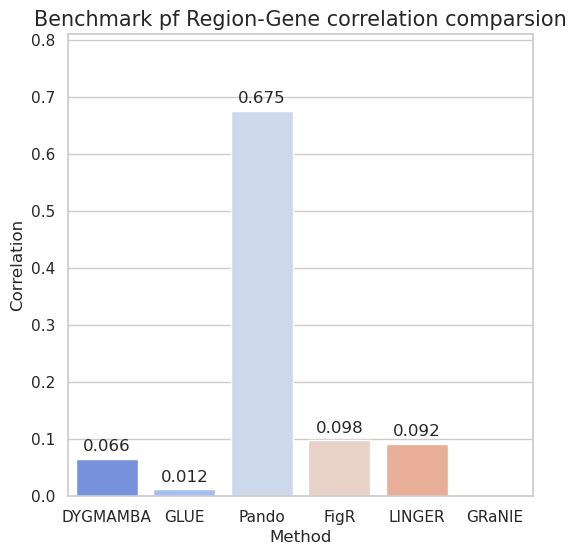

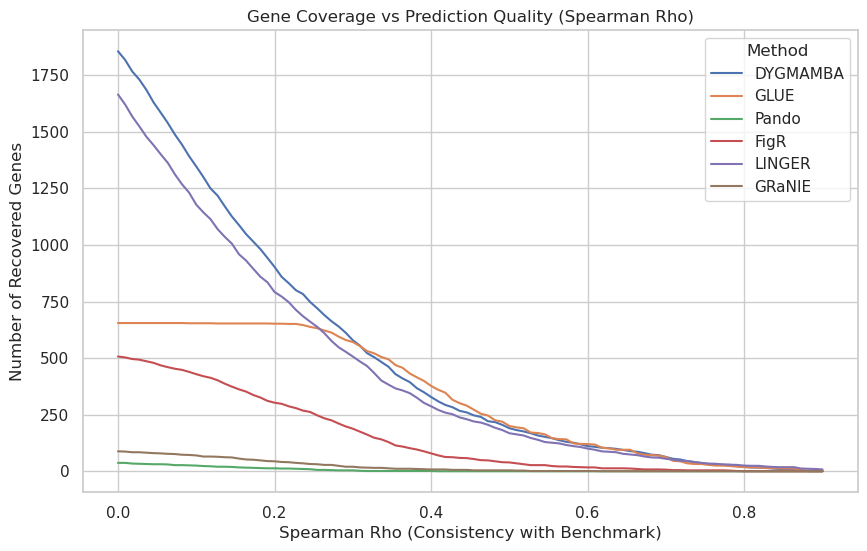

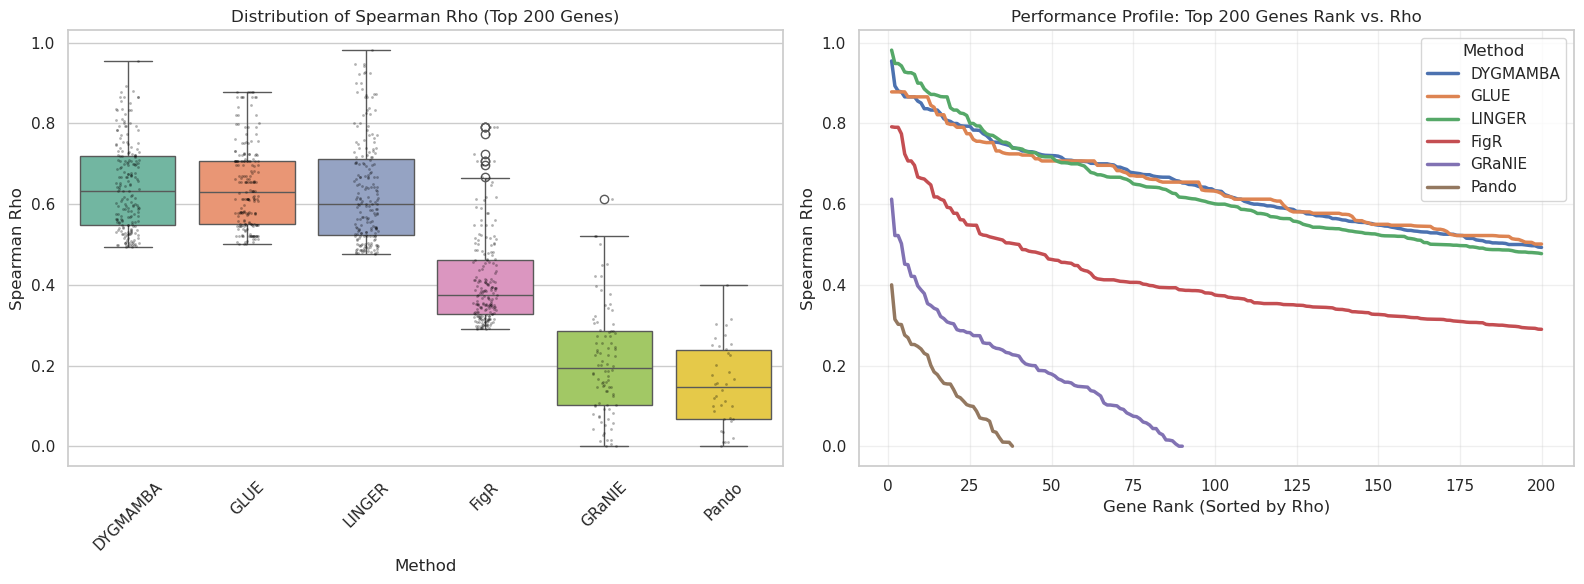

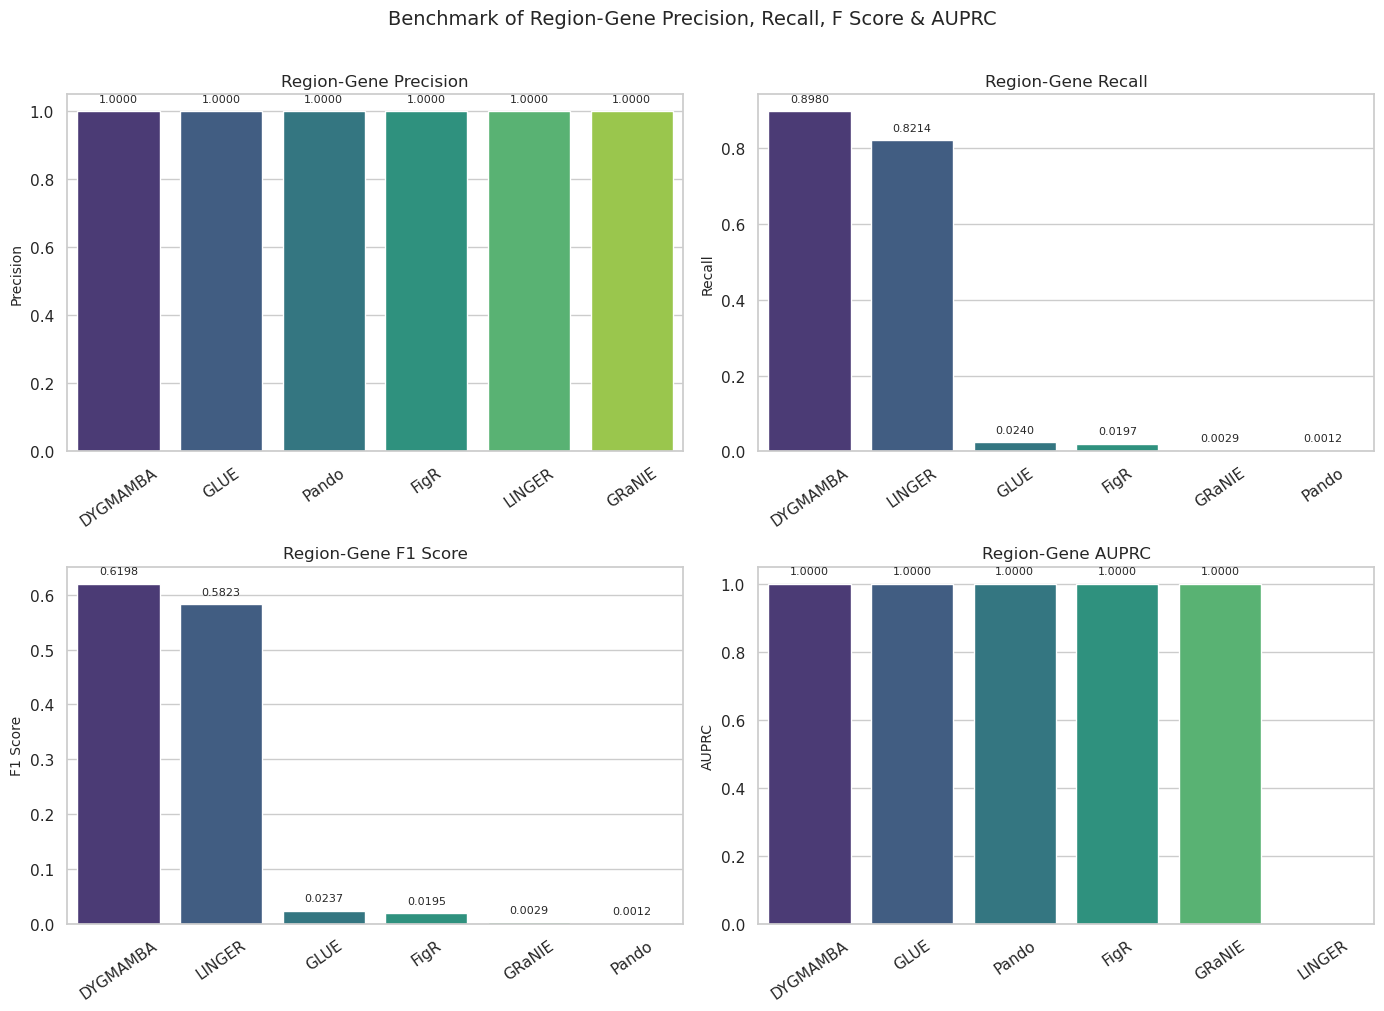

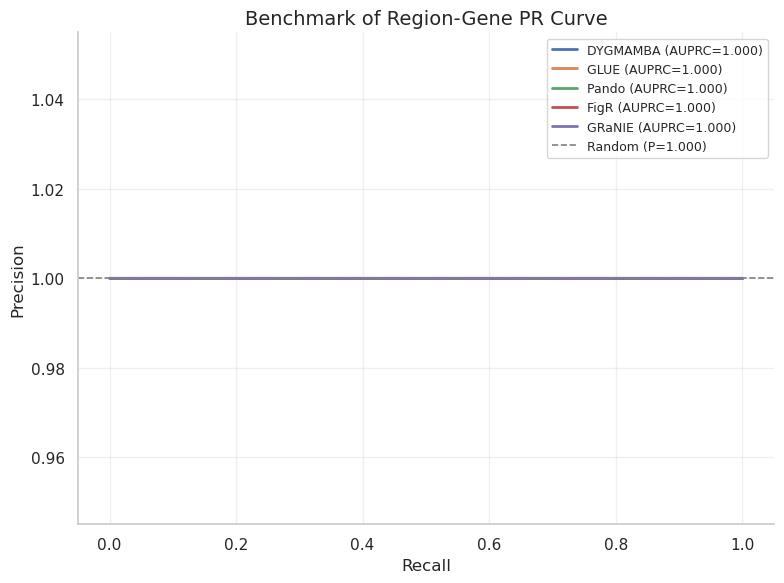

In [7]:

##############################################################################
#
# Region-Gene
#
##############################################################################
if flag_region_gene == True:
    
    results, method_data, benchmark_peak_gene_df = analysis_region_gene(data_path, output_path, method_list)

    #################################
    # Correlation

    plot_data = results.T.reset_index()
    plot_data.columns = ['Method', 'Correlation']

    # 2. 绘图
    plt.figure(figsize=(6, 6))
    sns.set_style("whitegrid") # 设置清爽的白色网格背景

    ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

    plt.title("Benchmark pf Region-Gene correlation comparsion", fontsize=15)
    plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间

    plt.savefig(output_path + 'Benchmark of Region-Gene Correlation Comparison.png', dpi=1200, bbox_inches='tight')


    #############################
    # score analysis

    corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)

    corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

    # 调用
    plot_recovery_curves(corr_df, 
                        output_file=output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                        compared_method='Abs_Spearman_Rho')

    plot_top_n_methods_comparison(corr_df, 
                                output_file=output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho.png',
                                top_n=200, compare_method='Abs_Spearman_Rho')
    # 补充分析 4（直接复用已有 method_data 和 benchmark_peak_gene_df）
    analysis_region_gene_precision(benchmark_peak_gene_df, method_data, output_path, beta=1.0)

# Test

In [28]:
from pdata.data_preprocess import dataframe_to_anndata_sparse, filter_jaspar_tf

jaspar_data = pd.read_pickle(data_path + "process/jaspar_df.pkl")

jaspar_anndata = dataframe_to_anndata_sparse(jaspar_data, obs_col="sequence_name", var_col="TF_Symbol", value_col="score")

jaspar_anndata.obs_names = jaspar_anndata.obs_names.str.replace(':', '-', regex=False)

# jaspar_data_processed = filter_jaspar_tf(jaspar_anndata)

jaspar_anndata.write_h5ad(data_path + "process/jaspar_data_processed.h5ad")

print(jaspar_anndata.X)


正在转换数据格式...
转换完成！AnnData shape: (64213, 850)
Obs (Regions): 64213, Var (TFs): 850
  (0, 17)	12.992
  (0, 19)	10.5319
  (0, 20)	8.93333
  (0, 22)	12.944
  (0, 23)	13.1441
  (0, 24)	13.016
  (0, 25)	12.8511
  (0, 33)	12.9789
  (0, 34)	10.5658
  (0, 47)	47.057719
  (0, 50)	10.6818
  (0, 53)	23.161299999999997
  (0, 54)	22.3114
  (0, 55)	79.69895
  (0, 56)	61.2857
  (0, 65)	10.7317
  (0, 78)	21.2623
  (0, 82)	11.9187
  (0, 85)	22.7305
  (0, 87)	47.5204
  (0, 88)	12.5517
  (0, 89)	20.913780000000003
  (0, 90)	25.7091
  (0, 99)	7.62903
  (0, 100)	10.1837
  :	:
  (64212, 416)	11.9014
  (64212, 417)	11.3496
  (64212, 453)	24.3262
  (64212, 458)	25.7021
  (64212, 497)	12.5333
  (64212, 560)	10.4878
  (64212, 572)	3.55172
  (64212, 608)	59.081399999999995
  (64212, 609)	26.0546
  (64212, 610)	65.347
  (64212, 611)	65.7798
  (64212, 683)	43.6179
  (64212, 702)	7.08197
  (64212, 704)	3.44262
  (64212, 705)	8.81818
  (64212, 713)	12.6129
  (64212, 715)	14.065
  (64212, 724)	-4.329262
  (64212, 739)

--- 1. 准备 ATAC Peak 数据 ---
未提供过滤列表，将使用 atac_adata 中所有的 Peaks。
ATAC Peaks 数量: 31421
--- 2. 准备 TF ChIP 数据 ---
TF ChIP Peaks 数量: 4274788
--- 3. 计算重叠 (构建 Network) ---
构建了包含 376918 条边的 TF-Peak 网络。
--- 4. 转换为矩阵 (Matrix Construction) ---
--- 5. 封装为 AnnData ---
✅ 完成！生成的 AnnData 维度: (31421, 73) (Peaks x TFs)

步骤 1: 过滤 Peaks (行)
  > 找到 40990 / 64213 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 717 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (40990, 717)
正在解析 Consensus Peaks 坐标...
共发现 16 个共有 TF，开始评估...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 22 个共有 TF，开始评估...
检测到冒号格式，正在统一为连字符格式...
正在解析 Consensus Peaks 坐标...
共发现 11 个共有 TF，开始评估...
格式已是连字符（chr1-100-200），无需转换。
正在解析 Consensus Peaks 坐标...
共发现 15 个共有 TF，开始评估...


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:903: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:903: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Method', y=score_col,
/tmp/ipykernel_77292/4116311844.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=tf_region_df_combined,
/tmp/ipykernel_77292/4116311844.py:96: FutureWarning: 

Passing `palette` w

[TF-Region Overall] DyGMamba | Macro Prec=0.7446 F=0.0535 | Micro Prec=0.6732 F=0.0619 | N=16
[TF-Region Overall] GLUE | Macro Prec=0.5654 F=0.1732 | Micro Prec=0.6347 F=0.1687 | N=22
[TF-Region Overall] LINGER | Macro Prec=0.1729 F=0.2569 | Micro Prec=0.1729 F=0.2569 | N=22
[TF-Region Overall] GRaNIE | Macro Prec=0.6162 F=0.0540 | Micro Prec=0.4783 F=0.0492 | N=11
[TF-Region Overall] Pando | Macro Prec=0.5444 F=0.0307 | Micro Prec=0.4857 F=0.0279 | N=15


/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.barplot(data=sorted_df, x="Method", y=col, palette="viridis", ax=ax)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.barplot(data=sorted_df, x="Method", y=col, palette="viridis", ax=ax)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:1696: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.b

✓ 已保存：TF-Region Overall Precision and F1
✓ 已保存：TF-Region Macro Precision vs F Score


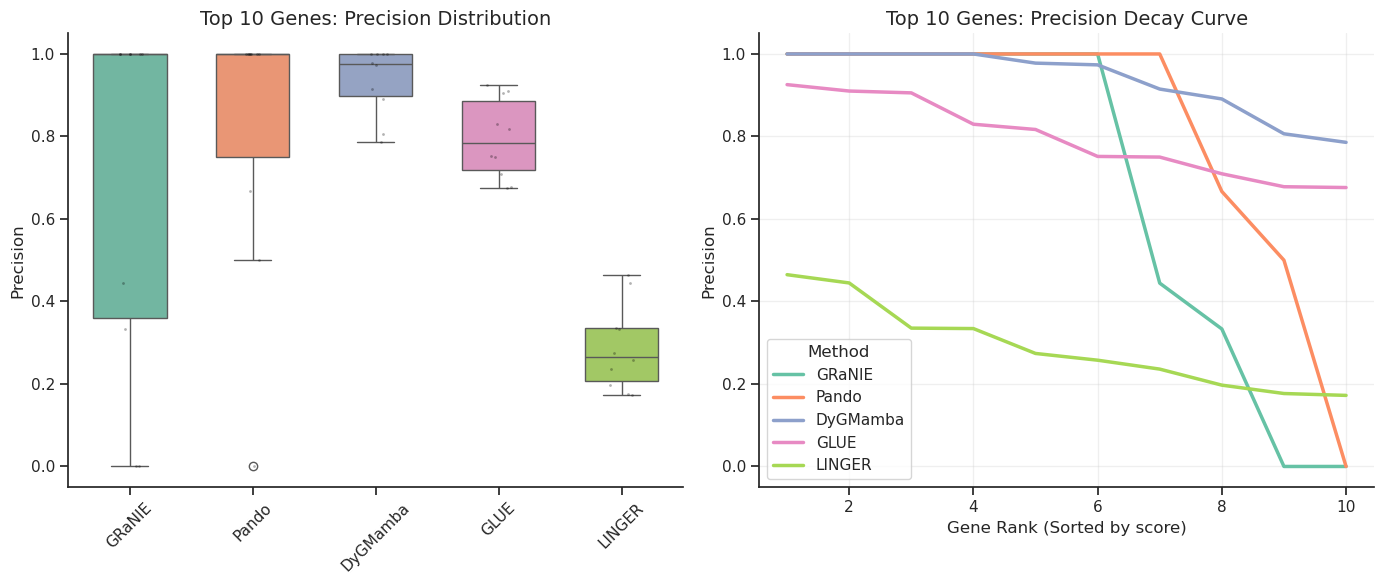

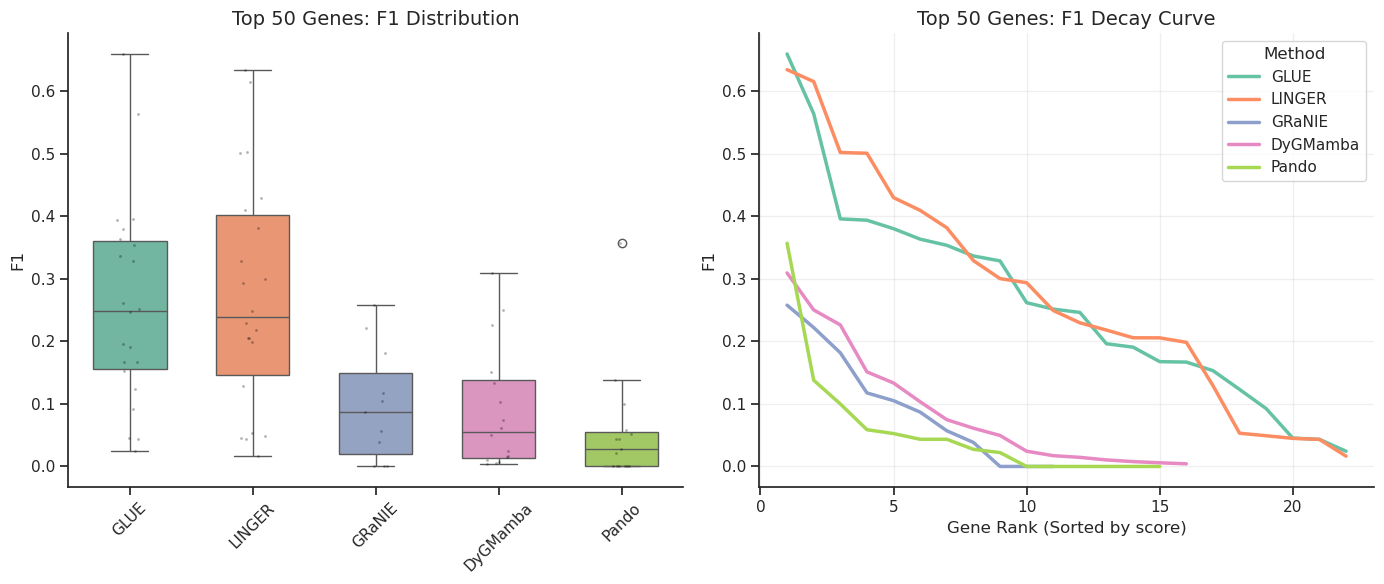

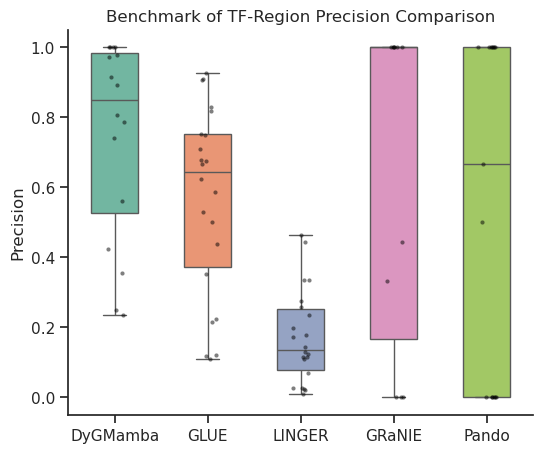

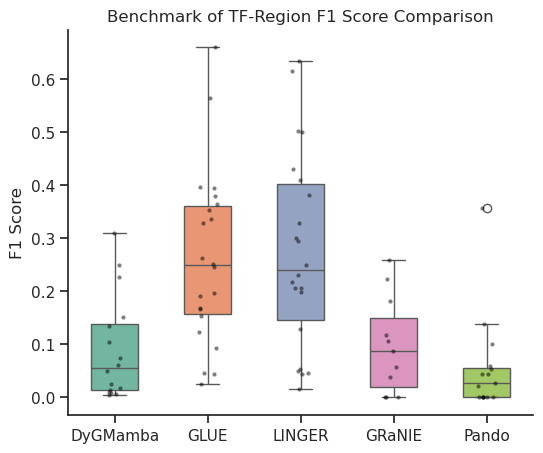

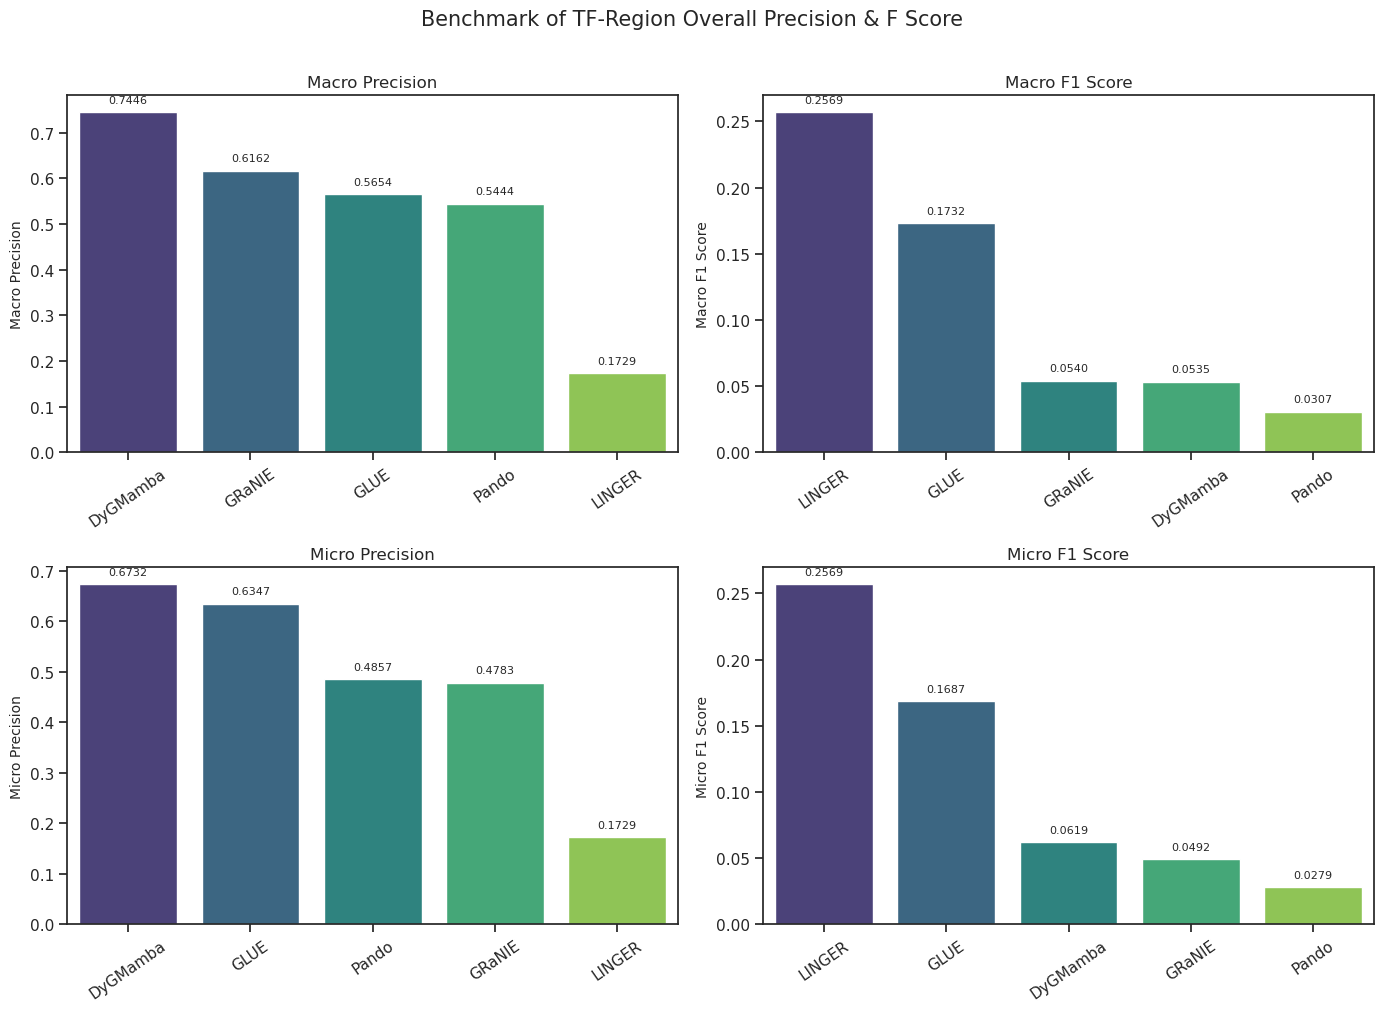

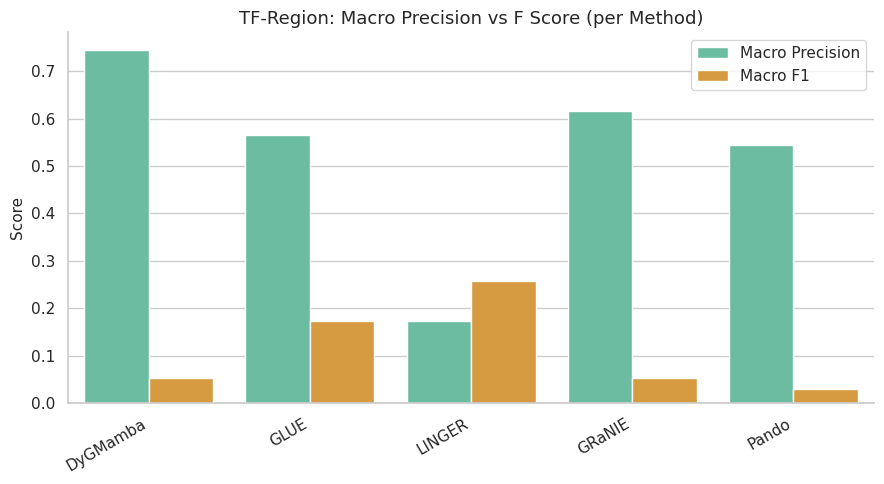

In [30]:
if flag_tf_region == True:
    ###################################
    # Benchmark

    f_score = 1

    tf_region_result = analysis_tf_region(unibind_df_file, data_path, f_score, method_list)


    ###################################
    # 

    # # 1. 准备数据字典
    # tf_region_result = {
    #     "DYGMAMBA": dyg_results,
    #     "GLUE": glue_results,
    #     "LINGER": linger_results,
    #     "GRaNIE": granie_results,
    #     "Pando": pando_results
    # }

    # 2. 调用函数
    # 例如：对比前 10 个基因的 Precision
    top_results = plot_top_n_comparison(
        method_dict=tf_region_result, 
        output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
        top_n=10, 
        score_col="Precision"
    )

    # 2. 调用函数
    # 例如：对比前 50 个基因的 Precision
    top_results = plot_top_n_comparison(
        method_dict= tf_region_result, 
        output_file= output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
        top_n= 50, 
        score_col= "F1"
    )


    ###########################
    # Boxplot
    ###########################
    # precisioin

    analysis_type = "Precision"
    tf_region_df = []

    for method_name, df in tf_region_result.items():

        tf_region_df.append(df[[analysis_type, 'Method']])

    tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

    # ==========================
    # @ 绘制箱形图
    # ==========================
    sns.set_theme(style="ticks")
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(data=tf_region_df_combined, 
                    x='Method',    # x轴放分组标签
                    y=analysis_type,        # y轴放数值
                    palette="Set2", # 配色方案
                    width=0.5)     # 箱子宽度

    sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
                color='black', size=3, alpha=0.5, jitter=True)

    plt.title("Benchmark of TF-Region Precision Comparison")
    plt.ylabel("Precision")
    plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
    sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

    plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')


    ################################
    # F1 score

    analysis_type = "F1"
    tf_region_df = []

    for method_name, df in tf_region_result.items():

        tf_region_df.append(df[[analysis_type, 'Method']])

    tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

    # =============================
    # @ 绘制箱形图
    # =============================
    sns.set_theme(style="ticks")
    plt.figure(figsize=(6, 5))

    ax = sns.boxplot(data=tf_region_df_combined, 
                    x='Method',    # x轴放分组标签
                    y=analysis_type,        # y轴放数值
                    palette="Set2", # 配色方案
                    width=0.5)     # 箱子宽度

    sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
                color='black', size=3, alpha=0.5, jitter=True)

    plt.title("Benchmark of TF-Region F1 Score Comparison")
    plt.ylabel("F1 Score")
    plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
    sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

    plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')
    
    # 补充分析 3（直接复用已有 tf_region_result）
    analysis_tf_region_overall(tf_region_result, output_path, beta=1.0)

In [17]:
print(jaspar_data)

          motif_id   TF_Symbol              sequence_name  start   end strand  \
0         MA2494.1      ZNF436       chr4:1809441-1810721     24    45      -   
1         MA2494.1      ZNF436     chr3:13650312-13651081     49    70      -   
2         MA1594.1      ZNF382   chr6:152969132-152970049     33    56      -   
3         MA1929.2        CTCF  chr10:123994297-123995000    472   502      +   
4         MA0088.3      ZNF143    chr19:55319664-55320224    306   328      +   
...            ...         ...                        ...    ...   ...    ...   
16354021  MA0159.1  RARA::RXRA    chr22:29553107-29554318   1106  1122      -   
16354022  MA0159.1  RARA::RXRA     chr2:15591080-15592376   1211  1227      -   
16354023  MA0159.1  RARA::RXRA    chr15:74540332-74542014   1257  1273      +   
16354024  MA0159.1  RARA::RXRA   chr5:172770525-172772804   1510  1526      +   
16354025  MA0159.1  RARA::RXRA      chr17:8118623-8122072   2744  2760      +   

             score       p-